---
title: "Primal and Dual Problems"
description: "Derive a Lagrangian dual and connect weak duality, strong duality, and KKT conditions."
author: "EulerLettersAI"
date: last-modified
jupyter: python3
format:
  html:
    code-fold: false
    code-links:
      - text: Download notebook
        icon: file-earmark-arrow-down
        href: 2.0-primal-and-dual.ipynb?download=1
execute:
  echo: true
  warning: false
---

## Setup

This notebook requires Python 3.11, NumPy, and Matplotlib. Run this command in a notebook cell once if they are not already installed:

```python
%pip install matplotlib==3.10.8 numpy==2.2.6
```

Restart the kernel after installation, then run the notebook from top to bottom.

In [1]:
#| label: setup
#| echo: true

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## Learning objectives

By the end of this notebook, you will be able to:

- write a problem in standard inequality form;
- construct its Lagrangian and dual function;
- explain weak and strong duality; and
- verify optimality using the KKT conditions.

## 1. The primal problem

The problem from the first notebook is

$$p^\star=\min_x (x-3)^2\quad\text{subject to}\quad x-1\leq0.$$

We call this the **primal problem**. We already know $x^\star=1$ and $p^\star=4$.

## 2. The Lagrangian and dual function

Associate a nonnegative multiplier $\lambda\geq0$ with the inequality $x-1\leq0$. The Lagrangian is

$$L(x,\lambda)=(x-3)^2+\lambda(x-1).$$

For a fixed $\lambda$, minimize over $x$. Stationarity gives

$$\frac{\partial L}{\partial x}=2(x-3)+\lambda=0
\quad\Longrightarrow\quad x(\lambda)=3-\frac{\lambda}{2}.$$

Substitution produces the dual function

$$g(\lambda)=\inf_x L(x,\lambda)=2\lambda-\frac{\lambda^2}{4}.$$

Every $g(\lambda)$ with $\lambda\geq0$ is a lower bound on the primal optimum.

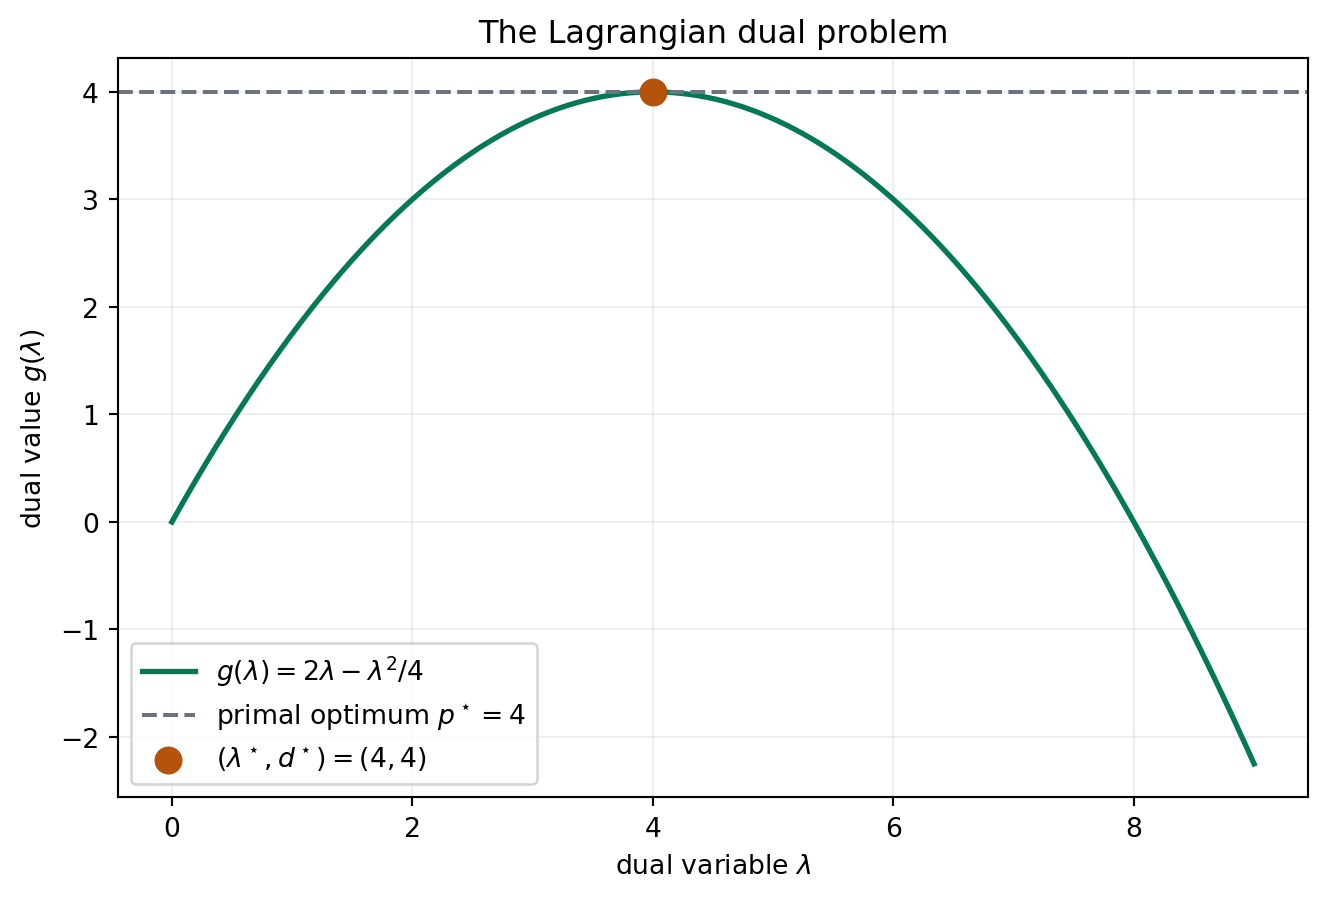

In [2]:
#| label: fig-dual-function
#| fig-cap: "The dual function gives lower bounds and reaches the primal optimum at lambda = 4."

lam = np.linspace(0, 9, 500)
g = 2 * lam - lam**2 / 4

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lam, g, color="#047857", linewidth=2, label=r"$g(\lambda)=2\lambda-\lambda^2/4$")
ax.axhline(4, color="#6b7280", linestyle="--", label=r"primal optimum $p^\star=4$")
ax.scatter([4], [4], color="#b45309", s=90, zorder=4, label=r"$(\lambda^\star,d^\star)=(4,4)$")
ax.set(xlabel=r"dual variable $\lambda$", ylabel=r"dual value $g(\lambda)$", title="The Lagrangian dual problem")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 3. Solve the dual problem

The **dual problem** chooses the tightest lower bound:

$$d^\star=\max_{\lambda\geq0}\left(2\lambda-\frac{\lambda^2}{4}\right).$$

Since $g'(\lambda)=2-\lambda/2$, the maximizer is $\lambda^\star=4$ and $d^\star=g(4)=4$. Thus

$$d^\star=p^\star=4.$$

Weak duality always gives $d^\star\leq p^\star$. Equality here is **strong duality**. This convex problem satisfies Slater's condition because, for example, $x=0$ is strictly feasible.

In [3]:
multipliers = np.array([0, 1, 2, 3, 4, 5, 6], dtype=float)
dual_bounds = 2 * multipliers - multipliers**2 / 4

print(" lambda    g(lambda)    gap p* - g(lambda)")
for value, bound in zip(multipliers, dual_bounds):
    print(f" {value:5.1f}    {bound:9.2f}    {4 - bound:17.2f}")

 lambda    g(lambda)    gap p* - g(lambda)
   0.0         0.00                 4.00
   1.0         1.75                 2.25
   2.0         3.00                 1.00
   3.0         3.75                 0.25
   4.0         4.00                 0.00
   5.0         3.75                 0.25
   6.0         3.00                 1.00


## 4. KKT conditions

For this convex problem, the Karush--Kuhn--Tucker conditions characterize the optimum:

1. **Primal feasibility:** $x^\star-1\leq0$.
2. **Dual feasibility:** $\lambda^\star\geq0$.
3. **Stationarity:** $2(x^\star-3)+\lambda^\star=0$.
4. **Complementary slackness:** $\lambda^\star(x^\star-1)=0$.

At $(x^\star,\lambda^\star)=(1,4)$, all four conditions hold. The positive multiplier tells us that the constraint is active and costly.

In [4]:
x_star = 1.0
lambda_star = 4.0

checks = {
    "primal feasible": x_star - 1 <= 0,
    "dual feasible": lambda_star >= 0,
    "stationarity residual": 2 * (x_star - 3) + lambda_star,
    "complementary-slackness residual": lambda_star * (x_star - 1),
}
checks

{'primal feasible': True,
 'dual feasible': True,
 'stationarity residual': 0.0,
 'complementary-slackness residual': 0.0}

## 5. What to remember

The primal problem searches over decision variables. The dual problem searches over constraint multipliers and produces bounds on the primal value. Strong duality makes the best bound exact, while the KKT conditions connect the two solutions.

### Exercises

1. Repeat the derivation for the constraint $x\leq2$.
2. What happens to $\lambda^\star$ when the constraint becomes $x\leq4$?
3. Interpret $\lambda^\star$ as the sensitivity of the optimal value to a small change in the constraint boundary.